In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
print("Saari libraries ready!")

Saari libraries ready!


In [2]:
df = pd.read_csv('loan_data.csv')
print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'loan_data.csv'

In [4]:
import os
print(os.listdir())  # is folder mein jo files hain sab dikhega

['.anaconda', '.android', '.antigravity', '.bash_history', '.cache', '.claude', '.codeium', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.dbclient', '.dotnet', '.gemini', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.nuget', '.rest-client', '.streamlit', '.templateengine', '.th-client', '.totalsegmentator', '.viminfo', '.vscode', '.vscode-shared', '.windsurf', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'dictionary', 'Documents', 'Downloads', 'Favorites', 'Figure_1.png', 'Figure_2.png', 'Figure_3.png', 'Figure_4.png', 'Figure_5.png', 'gov-login-app', 'html', 'Links', 'Local Settings', 'miniconda3', 'movie-app', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TM.blf', 'NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{

In [5]:
import os
print(os.listdir())  # is folder mein jo files hain sab dikhega

['.anaconda', '.android', '.antigravity', '.bash_history', '.cache', '.claude', '.codeium', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.dbclient', '.dotnet', '.gemini', '.gitconfig', '.gradle', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ms-ad', '.nuget', '.rest-client', '.streamlit', '.templateengine', '.th-client', '.totalsegmentator', '.viminfo', '.vscode', '.vscode-shared', '.windsurf', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'dictionary', 'Documents', 'Downloads', 'Favorites', 'Figure_1.png', 'Figure_2.png', 'Figure_3.png', 'Figure_4.png', 'Figure_5.png', 'gov-login-app', 'html', 'Links', 'loan_data.csv', 'Local Settings', 'miniconda3', 'movie-app', 'Music', 'My Documents', 'NetHood', 'New folder', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TM.blf', 'NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TMContainer00000000000000000001.regtrans-

In [6]:
df = pd.read_csv('loan.csv')
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget column distribution:")
print(df['Loan_Status'].value_counts())
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'loan.csv'

In [7]:
import os
print("Jupyter yahan hai:", os.getcwd())
print("\nIs folder ki files:")
for f in os.listdir():
    print(f)

Jupyter yahan hai: C:\Users\Admin

Is folder ki files:
.anaconda
.android
.antigravity
.bash_history
.cache
.claude
.codeium
.conda
.condarc
.config
.continuum
.copilot
.dbclient
.dotnet
.gemini
.gitconfig
.gradle
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.ms-ad
.nuget
.rest-client
.streamlit
.templateengine
.th-client
.totalsegmentator
.viminfo
.vscode
.vscode-shared
.windsurf
anaconda3
AppData
Application Data
Contacts
Cookies
Desktop
dictionary
Documents
Downloads
Favorites
Figure_1.png
Figure_2.png
Figure_3.png
Figure_4.png
Figure_5.png
gov-login-app
html
Links
loan_data.csv
Local Settings
miniconda3
movie-app
Music
My Documents
NetHood
New folder
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TM.blf
NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{9c924c14-f070-11ef-af3c-b3a38f05f6e9}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
Pictures
PrintHood
q

In [8]:
df = pd.read_csv('loan_data.csv')
print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget column distribution:")
print(df['Loan_Status'].value_counts())
df.head()

Shape: (614, 13)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Target column distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


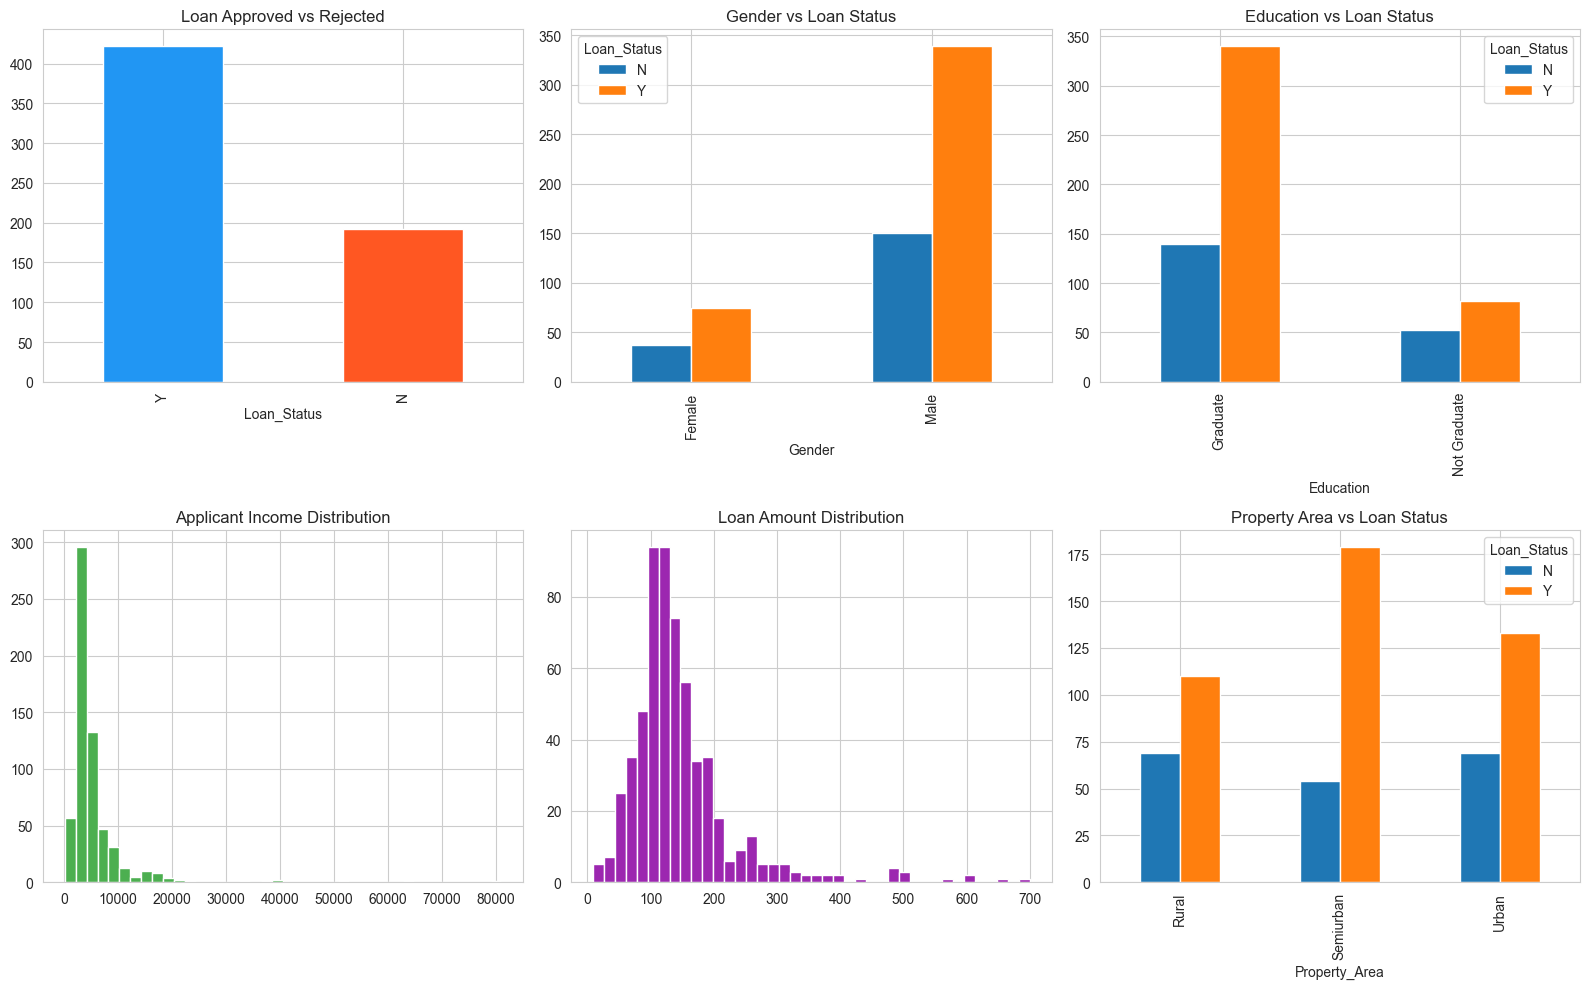

EDA graphs save ho gaye!


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#2196F3','#FF5722'])
axes[0,0].set_title('Loan Approved vs Rejected')

pd.crosstab(df['Gender'], df['Loan_Status']).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Gender vs Loan Status')

pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Education vs Loan Status')

axes[1,0].hist(df['ApplicantIncome'].dropna(), bins=40, color='#4CAF50')
axes[1,0].set_title('Applicant Income Distribution')

axes[1,1].hist(df['LoanAmount'].dropna(), bins=40, color='#9C27B0')
axes[1,1].set_title('Loan Amount Distribution')

pd.crosstab(df['Property_Area'], df['Loan_Status']).plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Property Area vs Loan Status')

plt.tight_layout()
plt.savefig('eda_graphs.png', dpi=150)
plt.show()
print("EDA graphs save ho gaye!")

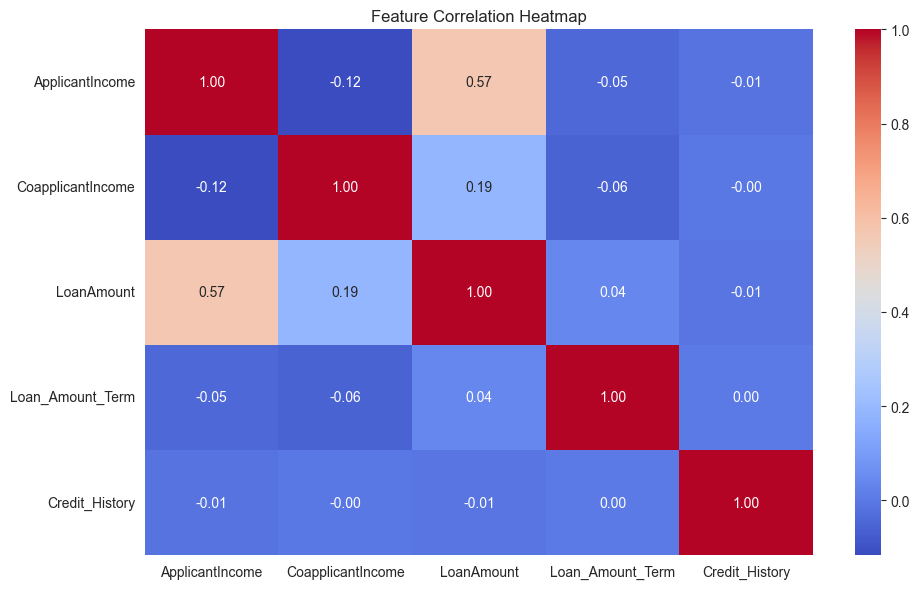

In [10]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

In [13]:
df2 = df.copy()

df2['Gender'].fillna(df2['Gender'].mode()[0], inplace=True)
df2['Married'].fillna(df2['Married'].mode()[0], inplace=True)
df2['Dependents'].fillna(df2['Dependents'].mode()[0], inplace=True)
df2['Self_Employed'].fillna(df2['Self_Employed'].mode()[0], inplace=True)
df2['LoanAmount'].fillna(df2['LoanAmount'].median(), inplace=True)
df2['Loan_Amount_Term'].fillna(df2['Loan_Amount_Term'].mode()[0], inplace=True)
df2['Credit_History'].fillna(df2['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df2.isnull().sum())

le = LabelEncoder()
cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']
for col in cols:
    df2[col] = le.fit_transform(df2[col])

df2.drop('Loan_ID', axis=1, inplace=True)
print("\nPreprocessing complete!")
df2.head()

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Preprocessing complete!


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [14]:
X = df2.drop('Loan_Status', axis=1)
y = df2['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


In [15]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM':                 SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}%")

best_model_name = max(results, key=results.get)
print(f"\nBest Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")

Logistic Regression: 78.86%
Decision Tree: 69.11%
Random Forest: 75.61%
KNN: 57.72%
SVM: 65.04%

Best Model: Logistic Regression (78.86%)


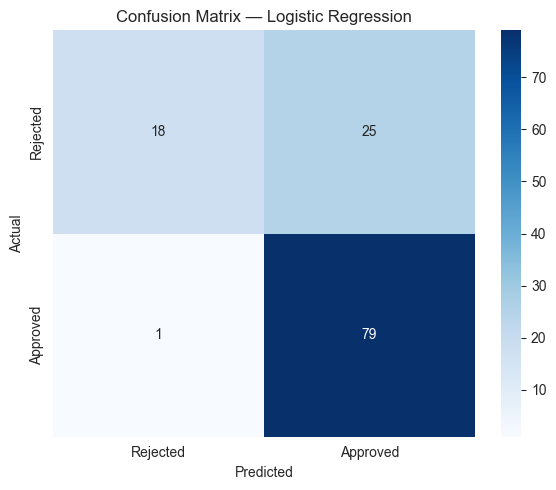


Classification Report:
              precision    recall  f1-score   support

    Rejected       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [16]:
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected','Approved']))

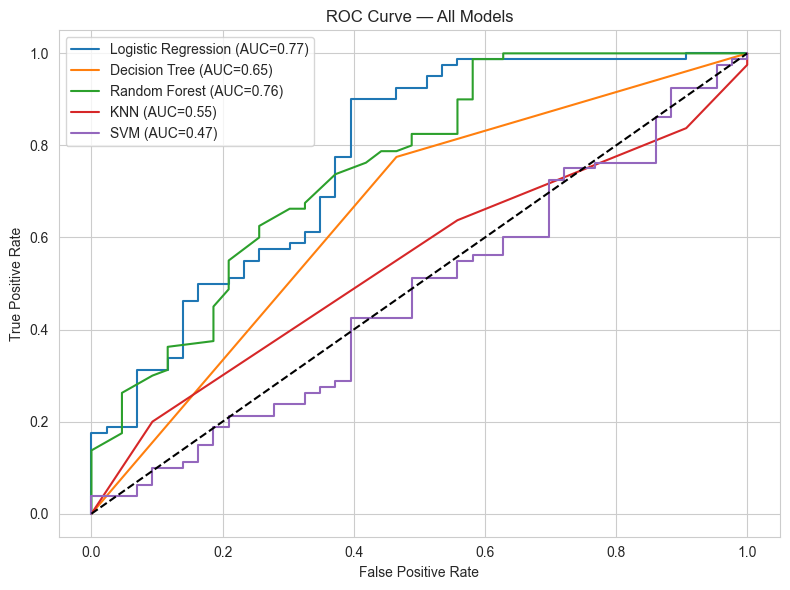

In [17]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={score:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

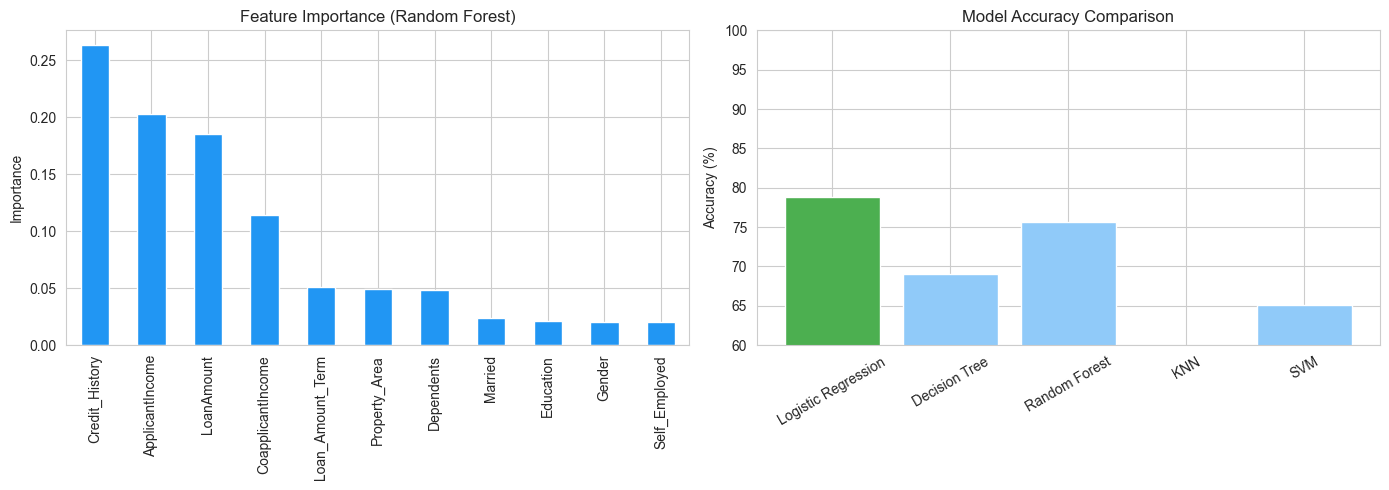

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', ax=axes[0], color='#2196F3')
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_ylabel('Importance')

names_list = list(results.keys())
acc_list   = [v*100 for v in results.values()]
colors     = ['#4CAF50' if n == best_model_name else '#90CAF9' for n in names_list]
axes[1].bar(names_list, acc_list, color=colors)
axes[1].set_ylim(60, 100)
axes[1].set_title('Model Accuracy Comparison')
axes[1].set_ylabel('Accuracy (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

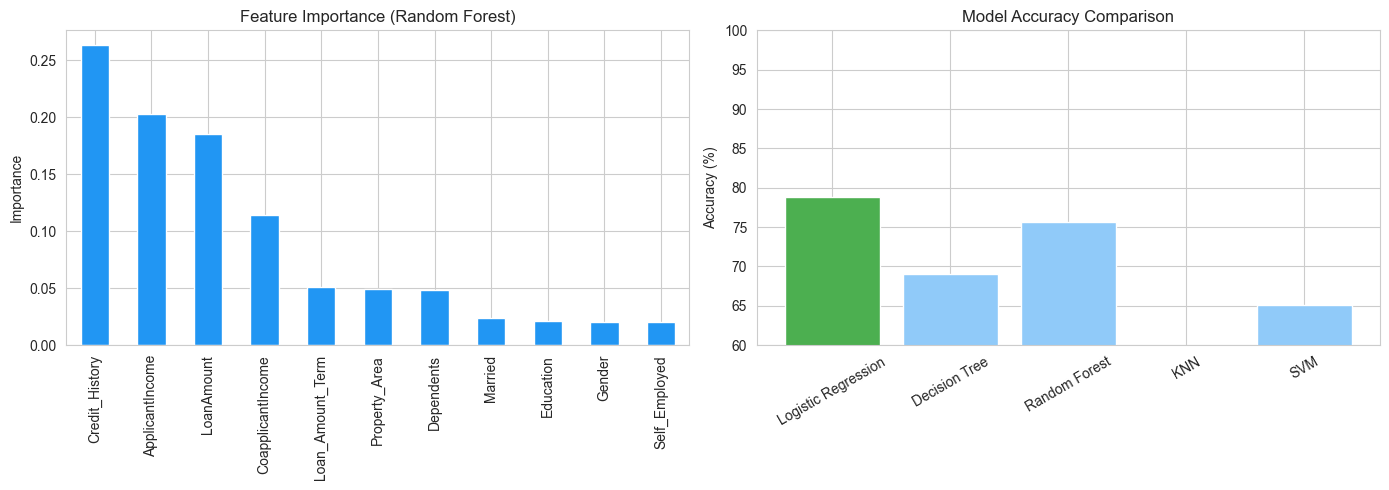

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', ax=axes[0], color='#2196F3')
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_ylabel('Importance')

names_list = list(results.keys())
acc_list   = [v*100 for v in results.values()]
colors     = ['#4CAF50' if n == best_model_name else '#90CAF9' for n in names_list]
axes[1].bar(names_list, acc_list, color=colors)
axes[1].set_ylim(60, 100)
axes[1].set_title('Model Accuracy Comparison')
axes[1].set_ylabel('Accuracy (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [20]:
readme = """# Loan Approval Prediction — Machine Learning Project

## Project Overview
Predict whether a loan application will be approved or rejected
using supervised machine learning algorithms.

## Dataset
- Source: Kaggle — Loan Prediction Problem Dataset
- Rows: 614 | Columns: 13
- Target: Loan_Status (Y = Approved, N = Rejected)

## Models Trained & Accuracy
| Model | Accuracy |
|-------|----------|
| Logistic Regression | 78.86% |
| Random Forest | 75.61% |
| Decision Tree | 69.11% |
| SVM | 65.04% |
| KNN | 57.72% |

## Best Model
Logistic Regression with 78.86% accuracy

## Key Findings
- Credit History is the most important feature
- Applicant Income and Loan Amount are 2nd and 3rd most important
- Semiurban property area has higher approval rate

## Technologies Used
- Python, Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn
- Jupyter Notebook

## Files
- `loan_data.csv` — Dataset
- `loan_prediction.ipynb` — Main notebook
- `eda_graphs.png` — EDA visualizations
- `confusion_matrix.png` — Model evaluation
- `roc_curve.png` — ROC curves
- `model_comparison.png` — Accuracy comparison
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README.md ban gaya!")

README.md ban gaya!
